In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
def data1():
    X=pd.read_csv('state_after_kmeans.csv')
    X = X.iloc[100:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [3]:
X=data1()
print(len(X))

2845


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\IIITNAGPUR\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


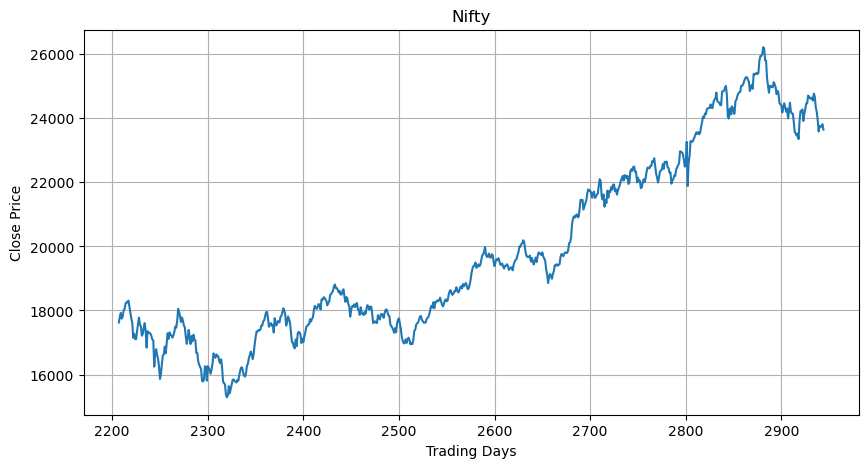

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
%pylab inline
fig = plt.figure()
ax=X.loc[2207:2944,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [5]:
len(X)

2845

In [6]:
X['Cluster'].value_counts()

Cluster
0.0    1648
1.0     736
4.0     276
3.0     168
5.0       9
2.0       8
Name: count, dtype: int64

In [7]:
X.head()

,Unnamed: 0,Close,High,Low,Open,Volume,date,weekday,month,SMA_10,...,CMF_20,FI_13,VROC_10,PVT,Cluster,cashopen,cash,action,diff,quantity
100,100,6104.299805,6125.049805,6069.799805,6120.450195,120200,29-05-2013,2,5,6097.199902,...,0.097321,-8.354134e+05,-21.897336,-3061.705179,0.0,0.0,0.0,,,
101,101,6124.049805,6133.750000,6072.149902,6072.149902,194100,30-05-2013,3,5,6092.614893,...,0.107417,3.833475e+06,22.383354,-2433.709319,0.0,0.0,0.0,,,
102,102,5985.950195,6106.250000,5975.549805,6098.700195,175300,31-05-2013,4,5,6072.479932,...,0.084902,-2.420886e+07,19.008826,-6386.789782,0.0,0.0,0.0,,,
103,103,5939.299805,6011.000000,5916.350098,5997.350098,112100,03-06-2013,0,6,6050.719922,...,0.033256,-5.229509e+06,-8.340147,-7260.420291,0.0,0.0,0.0,,,
104,104,5919.450195,5981.600098,5910.250000,5941.100098,114500,04-06-2013,1,6,6031.254932,...,-0.036799,-2.272780e+06,-12.327718,-7643.088353,0.0,0.0,0.0,,,


In [8]:
def getState(t):    
    t = int(t)
    return(X['Cluster'][t])  

In [9]:
class Agent:
    def __init__(self):
           
        self.gamma = np.load('rl/gamma100.npy')
        self.Q = np.load('rl/Qtable100.npy')
        self.learning_rate=np.load('rl/learning_rate100.npy')
        self.epsilon = np.load('rl/epsilon100.npy')
        print(self.epsilon)
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            #return random.choice(a)
            pass
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [10]:
episode_count=1
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=2207
    data_length=2944
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    X.loc[2,'cashopen']=margin 
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
       
        elif action == 2:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t)
        #print("Next state:", next_state)  # Debugging
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n")
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
       
    
    m3=roi
    if m3>m2:
          m1=e
          m2=m3
        #To save model  
    if e%1==0:
            np.save('rl/test/Qtable'+ str(e)+str('.npy'), agent.Q)
            np.save('rl/test/epsilon'+ str(e)+str('.npy'), agent.epsilon)
            np.save('rl/test/gamma'+ str(e)+str('.npy'), agent.gamma)
            np.save('rl/test/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
            X.to_csv('csv1/AfterTest'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

0.009998671593271896
Episod 1/30

***********************

Profit is  30520.598300000303
Initial Capital is  173871.50389999998
Current Capital is  204392.10220000028
%ROI is  17.553536729948483
% Buy and Hold= 36.95976543514558
count 735
qtable [[0.00534377 0.00539617 0.01250951]
 [0.0050824  0.00544873 0.00763247]
 [0.0007795  0.02614088 0.00166725]
 [0.00529707 0.00870846 0.00897817]
 [0.0060579  0.00783174 0.00793455]
 [0.00908883 0.00107323 0.0018761 ]]
epsilon 0.009998671593271896
--------------------------------
Episod 2/30

***********************

Profit is  63941.01802000048
Initial Capital is  173871.50389999998
Current Capital is  237812.52192000046
%ROI is  36.774869133688156
% Buy and Hold= 36.95976543514558
count 735
qtable [[0.00534377 0.00539617 0.01250951]
 [0.0050824  0.00544873 0.00746522]
 [0.0007795  0.0261888  0.00166725]
 [0.00529707 0.0083056  0.0085854 ]
 [0.0060579  0.00711039 0.00749984]
 [0.00916402 0.00107323 0.0018761 ]]
epsilon 0.009998671593271896
-----

In [11]:
agent.Q

array([[0.00534377, 0.00539617, 0.01250951],
       [0.0050824 , 0.00544873, 0.00753334],
       [0.0007795 , 0.0273731 , 0.00166725],
       [0.00529707, 0.00881687, 0.00805209],
       [0.0060579 , 0.00711039, 0.00754669],
       [0.01035734, 0.00107323, 0.0018761 ]])

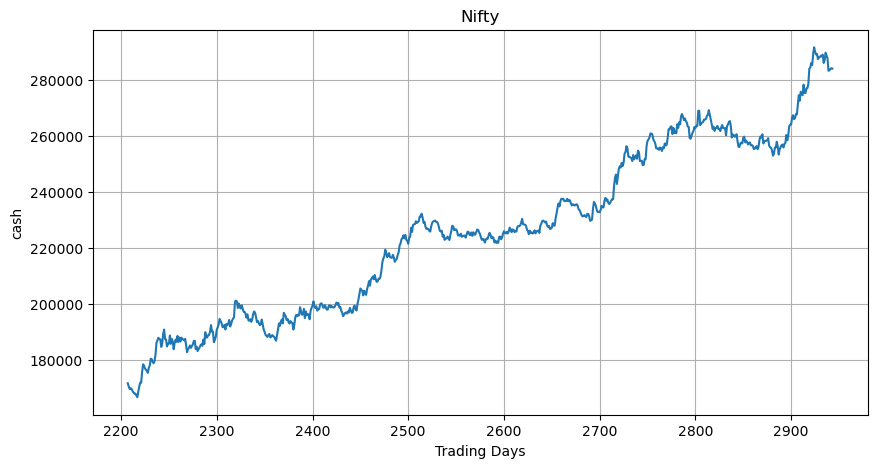

In [12]:
%matplotlib inline
#%pylab inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-1,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()
#fig.savefig('baroda_close.png')

In [13]:
2944-2207

737